In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

import sys
sys.path.append("/kaggle/input/models/minhkhanhdoan/deepland-cifar-100/pytorch/default/1")

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

# Transform cơ bản (có normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),

    transforms.AutoAugment(
        transforms.AutoAugmentPolicy.CIFAR10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5071, 0.4867, 0.4408),
        (0.2675, 0.2565, 0.2761)
    ),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5071, 0.4867, 0.4408),
        (0.2675, 0.2565, 0.2761)
    ),
])

In [3]:
trainset = torchvision.datasets.CIFAR100(
    root='/kaggle/working/data',
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR100(
    root='/kaggle/working/data',
    train=False,
    download=True,
    transform=test_transform
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2,  
    pin_memory=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

100%|██████████| 169M/169M [00:01<00:00, 85.3MB/s]


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PDPBlock(nn.Module):
    def __init__(self, in_channels, out_channels, s):
        super(PDPBlock, self).__init__()
        self.s = s

        # PW1
        self.pw1 = nn.Conv2d(in_channels, in_channels, 1, bias=False)
        self.bn_pw1 = nn.BatchNorm2d(in_channels)

        # DW1
        self.dw1 = nn.Conv2d(in_channels, in_channels, 3, stride=s, padding=1,
                             groups=in_channels, bias=False)
        self.bn_dw1 = nn.BatchNorm2d(in_channels)

        # DW2 (dilation)
        self.dw2 = nn.Conv2d(in_channels, in_channels, 3, stride=1, padding=2,
                             dilation=2, groups=in_channels, bias=False)
        self.bn_dw2 = nn.BatchNorm2d(in_channels)

        # PW2
        self.pw2 = nn.Conv2d(2 * in_channels, out_channels, 1, bias=False)
        self.bn_pw2 = nn.BatchNorm2d(out_channels)

        # SE
        self.SE = SE(out_channels, 16)

        # Residual
        self.PwR = nn.Conv2d(in_channels, out_channels, 1, stride=s, bias=False)
        self.bn_res = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        identity = x

        # PW1
        x = F.relu(self.bn_pw1(self.pw1(x)))

        # DW branches
        Dw1 = F.relu(self.bn_dw1(self.dw1(x)))
        Dw2 = F.relu(self.bn_dw2(self.dw2(x)))

        if self.s == 2:
            Dw2 = F.avg_pool2d(Dw2, 2)

        # concat + shuffle
        Dw = torch.cat([Dw1, Dw2], dim=1)
        Dw = self.shuffle(Dw)

        # PW2
        out = self.bn_pw2(self.pw2(Dw))
        out = self.SE(out)

        # Residual
        if self.s == 1 and identity.shape == out.shape:
            out = out + identity
        else:
            out = out + self.bn_res(self.PwR(identity))

        return F.relu(out)

    def shuffle(self, x):
        b, c, h, w = x.size()
        g = 2
        x = x.view(b, g, c // g, h, w)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        return x.view(b, c, h, w)

class NetFinal(nn.Module):
    def __init__(self, image_size, n_class=100):
        super(NetFinal, self).__init__()
        self.image_size = image_size
        small_input = image_size <= 64

        stem_stride = 1 if small_input else 2
        block3_stride = 1 if small_input else 2
        block8_stride = 1 if small_input else 2
        block10_stride = 1 if small_input else 2
 
        self.conv1 = nn.Conv2d(3, 32, 3, stride=stem_stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.block1 = PDPBlock(in_channels=32, out_channels=64, s=1)
        self.block2 = PDPBlock(in_channels=64, out_channels=64, s=1)
        self.block3 = PDPBlock(in_channels=64, out_channels=128, s=block3_stride)
        self.block5 = PDPBlock(in_channels=128, out_channels=128, s=1)
        self.block6 = PDPBlock(in_channels=128, out_channels=256, s=2)
        self.block7 = PDPBlock(in_channels=256, out_channels=256, s=1)
        self.block8 = PDPBlock(in_channels=256, out_channels=256, s=block8_stride)
        self.block9 = PDPBlock(in_channels=256, out_channels=512, s=1)
        self.block10 = PDPBlock(in_channels=512, out_channels=512, s=block10_stride)
        self.conv2 = nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=1, stride=1, padding=0)
        self.bn2 = nn.BatchNorm2d(1024)
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        self.dropout = nn.Dropout(p=4 if small_input else 0.3)
        self.fc = nn.Linear(1024, n_class)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)
        x = self.block10(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)

net = NetFinal(image_size=224,n_class=100)
net.to(device)
from torchsummary import summary
print(net)
summary(net, (3, 32, 32))

NetFinal(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): PDPBlock(
    (pw1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn_pw1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dw1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
    (bn_dw1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dw2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=32, bias=False)
    (bn_dw2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pw2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn_pw2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (SE): SE(
      (ChannelGate): ChannelGate(
    

In [7]:
import time
import torch

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

In [8]:
import torch

def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    scaler=None,
    is_train=True
):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad()

            # ===== AMP =====
            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

In [9]:
import time
import torch
import json
import os
from torch.cuda.amp import GradScaler
from train_utils import save_history_csv, save_plots
model = net
train_loader = trainloader
test_loader = testloader

scaler = GradScaler(enabled=(device.type == "cuda"))
scheduler = None
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}
cfg = {
    "epochs": 200
}
best = {"epoch": 0, "test_acc": 0.0}
output_root = "/kaggle/working"
os.makedirs(output_root, exist_ok=True)
for epoch in range(1, cfg["epochs"] + 1):
    t0 = time.time()

    # ===== TRAIN =====
    model.train()
    train_loss, train_acc = run_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        scaler=scaler,
        is_train=True
    )

    # ===== TEST =====
    model.eval()
    with torch.no_grad():
        test_loss, test_acc = run_one_epoch(
            model=model,
            loader=test_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
            scaler=None,
            is_train=False
        )

    if scheduler is not None:
        scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch [{epoch}/{cfg['epochs']}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}% | "
        f"Time: {time.time() - t0:.1f}s"
    )

    save_history_csv(history, f"{output_root}/history.csv")

    if test_acc > best["test_acc"]:
        best = {"epoch": epoch, "test_acc": test_acc}
        print(f"[BEST] Epoch {epoch} | Acc: {test_acc:.2f}%")

        torch.save(model.state_dict(), f"{output_root}/best.pth")

print("BEST:", best)

/tmp/ipykernel_24/1739169640.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))


Epoch [1/200] | Train Loss: 4.2795 | Train Acc: 5.43% | Test Acc: 11.64% | Time: 34.0s
[BEST] Epoch 1 | Acc: 11.64%
Epoch [2/200] | Train Loss: 3.8974 | Train Acc: 10.37% | Test Acc: 18.52% | Time: 25.6s
[BEST] Epoch 2 | Acc: 18.52%
Epoch [3/200] | Train Loss: 3.6386 | Train Acc: 14.43% | Test Acc: 23.86% | Time: 25.8s
[BEST] Epoch 3 | Acc: 23.86%
Epoch [4/200] | Train Loss: 3.4144 | Train Acc: 17.83% | Test Acc: 27.32% | Time: 25.5s
[BEST] Epoch 4 | Acc: 27.32%
Epoch [5/200] | Train Loss: 3.2269 | Train Acc: 21.31% | Test Acc: 31.34% | Time: 25.9s
[BEST] Epoch 5 | Acc: 31.34%
Epoch [6/200] | Train Loss: 3.0604 | Train Acc: 24.48% | Test Acc: 34.14% | Time: 25.9s
[BEST] Epoch 6 | Acc: 34.14%
Epoch [7/200] | Train Loss: 2.9296 | Train Acc: 26.73% | Test Acc: 36.97% | Time: 25.8s
[BEST] Epoch 7 | Acc: 36.97%
Epoch [8/200] | Train Loss: 2.8178 | Train Acc: 28.95% | Test Acc: 38.44% | Time: 25.6s
[BEST] Epoch 8 | Acc: 38.44%
Epoch [9/200] | Train Loss: 2.7140 | Train Acc: 31.06% | Test Acc

In [10]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # ===== LOSS =====
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # ===== ACC =====
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

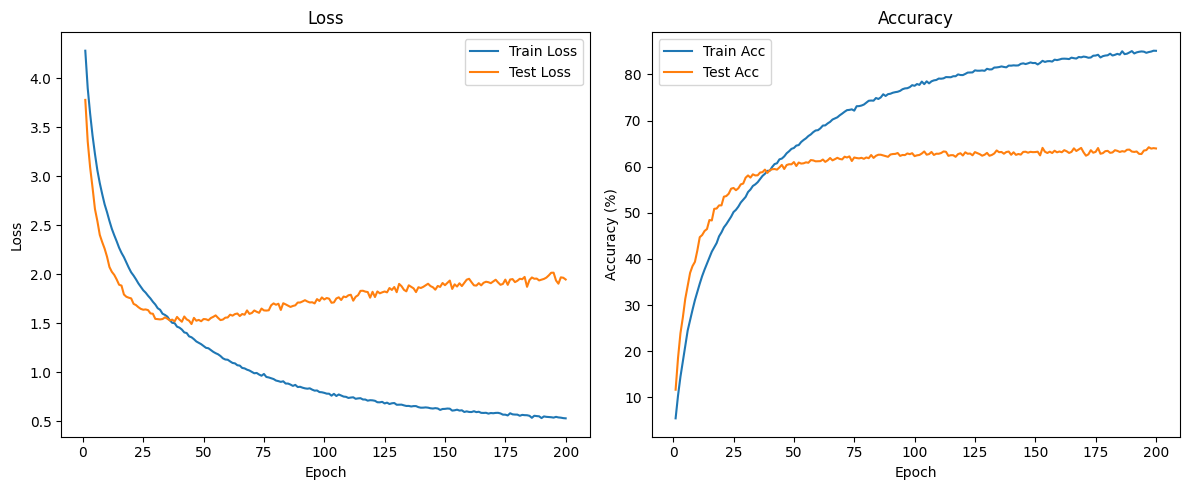

In [11]:
plot_history(history)